In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torchvision.models import VGG16_Weights

In [2]:
from priorbox import AnchorBoxes
import yaml
from utils import normalised_gt_coords,corner_to_center,iou,center_to_corner,decode,encode 

with open('config/priorbox.yaml', 'r') as file:
        config = yaml.safe_load(file)

boxes=AnchorBoxes(config)
anchors=boxes.forward()
gt_boxes = [
    (75, 80, 60, 90),
    (220, 70, 50, 40),
    (150, 170, 140, 110),
    (260, 240, 70, 120),
    (45, 230, 80, 60)
]
gtboxes=torch.tensor(gt_boxes, dtype=torch.float32)



In [3]:
anchors

tensor([[0.0718, 0.0718, 0.1435, 0.1435],
        [0.0849, 0.0718, 0.1699, 0.1435],
        [0.0981, 0.0718, 0.1962, 0.1435],
        ...,
        [0.5000, 0.5000, 0.9000, 0.9000],
        [0.5000, 0.5000, 1.0000, 0.6364],
        [0.5000, 0.5000, 0.6364, 1.0000]])

In [4]:

anch=center_to_corner(anchors)
gt=center_to_corner(normalised_gt_coords(gtboxes,300,300))

In [5]:
intersection=iou(anch,gt)
intersection

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0064, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0143, 0.0000, 0.0000, 0.0000, 0.0000],
        ...,
        [0.0741, 0.0274, 0.2112, 0.0840, 0.0571],
        [0.0723, 0.0308, 0.2689, 0.0750, 0.0622],
        [0.0781, 0.0349, 0.2689, 0.0388, 0.0303]])

In [6]:
intersection.shape

torch.Size([8732, 5])

In [7]:
labels=torch.tensor([1,2,3,1,2]).unsqueeze(1)
labels

tensor([[1],
        [2],
        [3],
        [1],
        [2]])

In [8]:
gt

tensor([[0.1500, 0.1167, 0.3500, 0.4167],
        [0.6500, 0.1667, 0.8167, 0.3000],
        [0.2667, 0.3833, 0.7333, 0.7500],
        [0.7500, 0.6000, 0.9833, 1.0000],
        [0.0167, 0.6667, 0.2833, 0.8667]])

In [9]:



# for each gt best overlap ;
for_gt_id=intersection.argmax(dim=0)
# for each anchort best overlap 
for_anchor_iou,for_anchor_idx, = intersection.max(dim=1)

for i in range(gt.shape[0]):
    #for each gtbox look at assigned best anchor 
    best_assigned_anchor=for_gt_id[i]
    #for this best assigned anchor the associated gtbox has to be this gtbox at index i 
    for_anchor_idx[best_assigned_anchor]=i 
    #to make sure we dont drop this in next lines 
    for_anchor_iou[best_assigned_anchor]=1

#after we have forced to make sure every gt box gets one anchor we do class assignment

for_anchor_classes=labels[for_anchor_idx]
for_anchor_classes[for_anchor_iou<0.5]=0

for_anchor_coords=gt[for_anchor_idx]
for_anchor_coords[for_anchor_iou<0.5]=0

for_anchor_coords_encoded=encode(for_anchor_coords,anch,[0.1, 0.2])
#finally i get for_anchor_classes, for_anchor_coords


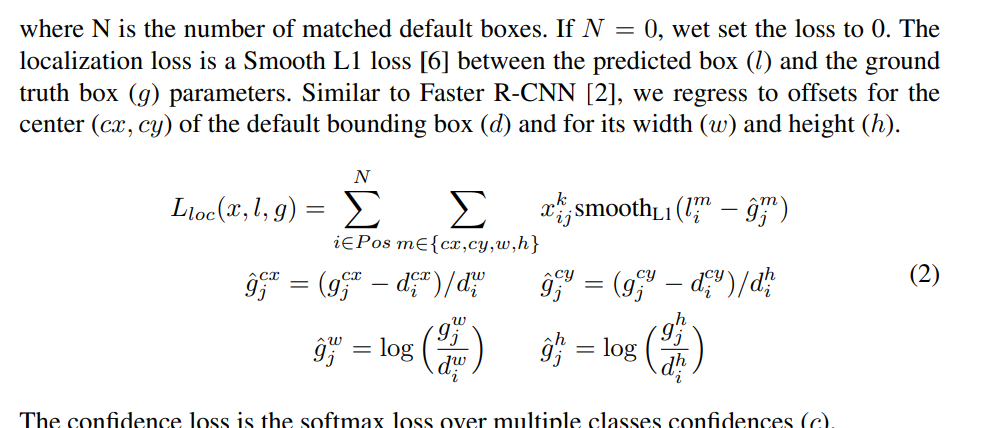

In [12]:
for_anchor_classes

tensor([[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]])

In [11]:
for_anchor_coords

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [18]:
encoded=encode(for_anchor_coords,anch)
decode(encoded,anch)[312]

TypeError: encode() missing 1 required positional argument: 'variances'

In [103]:
for_anchor_coords[312]

tensor([0.1500, 0.1167, 0.3500, 0.4167])

In [70]:
for_anchor_coords.shape==anch.shape

True

In [10]:
vgg = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features
vgg[16] = nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/onyxia/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100.0%


In [11]:
base=nn.ModuleList(vgg[:30])#until 5_3 layer

In [12]:
base
convs={}
i=1
convid=1
print("----","conv",0,"----")

for id, el in enumerate(base):

    print(f"({id})",el )
    if isinstance(el,nn.Conv2d):
        
        convs[id]=f"{i}_{convid}"
        convid=convid+1
    if isinstance(el,nn.MaxPool2d):
        convid=1
        print("----","conv",i,"----")
        i=i+1
    

    

    
    

---- conv 0 ----
(0) Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
(1) ReLU(inplace=True)
(2) Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
(3) ReLU(inplace=True)
(4) MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
---- conv 1 ----
(5) Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
(6) ReLU(inplace=True)
(7) Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
(8) ReLU(inplace=True)
(9) MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
---- conv 2 ----
(10) Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
(11) ReLU(inplace=True)
(12) Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
(13) ReLU(inplace=True)
(14) Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
(15) ReLU(inplace=True)
(16) MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
---- conv 3 ----
(17) Conv2d(256, 512, kernel_s

In [13]:
convs

{0: '1_1',
 2: '1_2',
 5: '2_1',
 7: '2_2',
 10: '3_1',
 12: '3_2',
 14: '3_3',
 17: '4_1',
 19: '4_2',
 21: '4_3',
 24: '5_1',
 26: '5_2',
 28: '5_3'}

In [14]:
from l2norm import L2norm
class SSD(nn.Module):
    def __init__(self,base,nb_classes):
        super().__init__()
        self.features=base
        self.nb_classes=nb_classes

        self.l2norm=L2norm(512,20)

        self.extras=nn.ModuleList([
            #conv6 and conv7
            nn.Sequential(
                nn.Conv2d(in_channels=512,out_channels=1024,kernel_size=3,padding=6,dilation=6),
                nn.ReLU(inplace=True),
                nn.Conv2d(in_channels=1024,out_channels=1024,kernel_size=1),
                nn.ReLU(inplace=True),    
            ),

            #conv8_2
            nn.Sequential(
                nn.Conv2d(in_channels=1024,out_channels=256,kernel_size=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3,padding=1,stride=2),
                nn.ReLU(inplace=True),    
            ),

            #conv9_2
            nn.Sequential(
                nn.Conv2d(in_channels=512,out_channels=128,kernel_size=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,padding=1,stride=2),
                nn.ReLU(inplace=True),    
            ),

            #conv10_2
            nn.Sequential(
                nn.Conv2d(in_channels=256,out_channels=128,kernel_size=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3),
                nn.ReLU(inplace=True),    
            ),

            #conv11_2
            nn.Sequential(
                nn.Conv2d(in_channels=256,out_channels=128,kernel_size=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3),
                nn.ReLU(inplace=True),    
            )
        ])

        #define kernels for classification to output Feature Map of sieze H,W,ki*nb_classes for all H,W, ki in {4,6} for all i =1 ... |ssd feature maps | , ki is number of anchors for each location of H,W, image 
        self.classification_convolutions=nn.ModuleList([

            nn.Conv2d(512,4*nb_classes,kernel_size=3,padding=1),
            nn.Conv2d(1024,6*nb_classes,kernel_size=3,padding=1),
            nn.Conv2d(512,6*nb_classes,kernel_size=3,padding=1),
            nn.Conv2d(256,6*nb_classes,kernel_size=3,padding=1),
            nn.Conv2d(256,4*nb_classes,kernel_size=3,padding=1),
            nn.Conv2d(256,4*nb_classes,kernel_size=3,padding=1),
        ])

        #same but using 4 coordinates for each anchor 
        self.regression_convolutions=nn.ModuleList([

            nn.Conv2d(512,4*4,kernel_size=3,padding=1),
            nn.Conv2d(1024,6*4,kernel_size=3,padding=1),
            nn.Conv2d(512,6*4,kernel_size=3,padding=1),
            nn.Conv2d(256,6*4,kernel_size=3,padding=1),
            nn.Conv2d(256,4*4,kernel_size=3,padding=1),
            nn.Conv2d(256,4*4,kernel_size=3,padding=1),

        ])
    def forward(self, X):
        layers_for_prediction = []
      
        #base model 
        for idx in range(len(self.features)):

            X=self.features[idx](X)
            
            if idx in convs and convs[idx]=="4_3":
                # print(self.features[idx])
                # print(X.shape)

                X=self.l2norm(X)
                layers_for_prediction.append(X)
          
                
        for idx in range(len(self.extras)):
            X=self.extras[idx](X)
            
            layers_for_prediction.append(X)


        classifications=[]    
        for layer_for_predictions, classification_convolution in zip( layers_for_prediction, self.classification_convolutions):

            x=classification_convolution(layer_for_predictions)
            #then we want to get for all i,j in H*H and all k in 1....K -> p1.....pC probabilities of C classes
            """

            mathematically : 

            anchors=6
            total=6*21
            classes=21
            N=10
            H=19
            x=torch.randn((N,H,H,total))
            x.view(N,H,H,anchors,int(total/anchors)).shape

            x.view(N,H,H,anchors,int(total/anchors)).view(N,H*H*anchors,classes).shape

            However, this iplementation is slower as need to track nb_anchors and do manual calculations 
            which will slow down the process, this is why we do more standard code (this comment is for self learning purpose)
            """
            classifications.append(x.permute(0,2,3,1).contiguous())
        
        regressions=[]  
        for layer_for_predictions, regression_convolution in zip( layers_for_prediction, self.regression_convolutions):
            x=regression_convolution(layer_for_predictions)
            regressions.append(x.permute(0,2,3,1).contiguous())

        #this efficient code was taken from degroot/ssd.pytorch github and is equivalent to my code in comment
        
        loc = torch.cat([o.view(o.size(0), -1) for o in regressions], 1)
        conf = torch.cat([o.view(o.size(0), -1) for o in classifications], 1)


        locs = loc.view(loc.size(0), -1, 4)#so we get for every image 2D matrix for classification and regression : 8732 anchor boxes and nb coords/classes
        #8732 anchor boxes are sum of all anchor boxes across all ft map k =  of sum over k (Hk*Hk*ak) 
        #for standard ssd300 it is 38*38*4+19*19*6+100*6+25*6+9*4+4
        confs = conf.view(conf.size(0), -1, self.nb_classes)

        return locs,confs,layers_for_prediction



In [15]:
X=torch.randn((10,3,300,300))

model=SSD(base,21)
classifications,regressions,layers_for_prediction=model.forward(X)

In [16]:
classifications.shape

torch.Size([10, 8732, 4])

In [17]:
regressions.shape



torch.Size([10, 8732, 21])

In [30]:
for el  in layers_for_prediction:
    print(el.shape[2:])



torch.Size([38, 38])
torch.Size([19, 19])
torch.Size([10, 10])
torch.Size([5, 5])
torch.Size([3, 3])
torch.Size([1, 1])
